Path to dataset files: /kaggle/input/water-bodies-segmentation-dataset-with-split
Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 106s 840ms/step - accuracy: 0.6632 - loss: 0.6375 - val_accuracy: 0.6787 - val_loss: 0.5820
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 89s 572ms/step - accuracy: 0.7144 - loss: 0.5530 - val_accuracy: 0.7509 - val_loss: 0.5286
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 82s 576ms/step - accuracy: 0.7742 - loss: 0.4839 - val_accuracy: 0.7478 - val_loss: 0.5114
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 82s 579ms/step - accuracy: 0.7782 - loss: 0.4809 - val_accuracy: 0.7626 - val_loss: 0.4750
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 83s 593ms/step - accuracy: 0.7681 - loss: 0.4832 - val_accuracy: 0.7707 - val_loss: 0.4478
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 82s 595ms/step - accuracy: 0.7659 - loss: 0.4941 - val_accuracy: 0.7650 - val_loss: 0.4737
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 582ms/step - accuracy: 0.7830 - loss: 0.4676 - val_accuracy: 0.7696 - val_loss: 0.4667
Epoch 8/30
75/

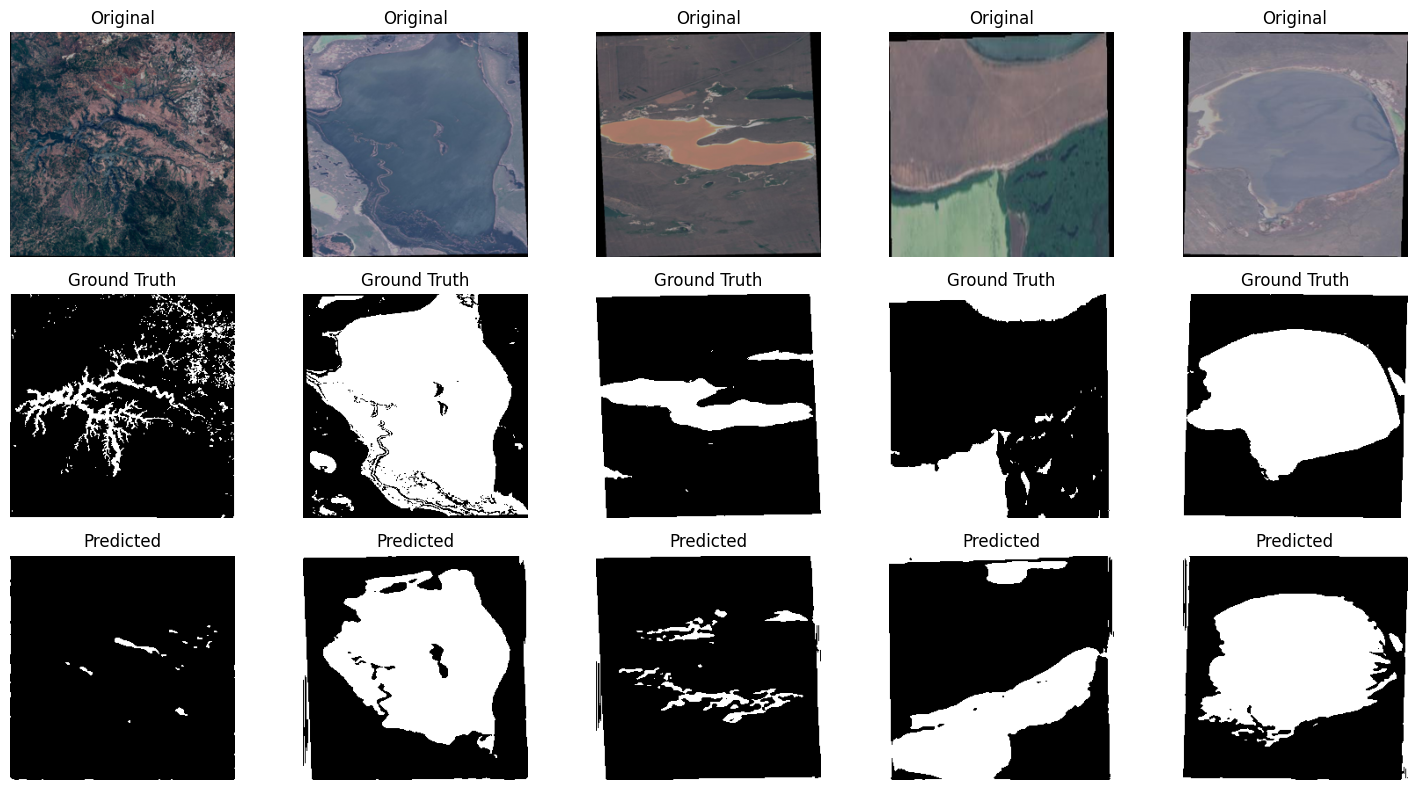

In [ ]:
import kagglehub
import os
import glob
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Download dataset
base_path = kagglehub.dataset_download("sovitrath/water-bodies-segmentation-dataset-with-split")
print("Path to dataset files:", base_path)

# Setup directories
image_dir = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'train_images')
mask_dir = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'train_masks')
image_dir1 = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'valid_images')
mask_dir1 = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'valid_masks')

# Gather image paths
all_images_train = sorted(glob.glob(os.path.join(image_dir, '*.jpg')))
all_masks_train = sorted(glob.glob(os.path.join(mask_dir, '*.jpg')))
all_images_valid = sorted(glob.glob(os.path.join(image_dir1, '*.jpg')))
all_masks_valid = sorted(glob.glob(os.path.join(mask_dir1, '*.jpg')))

# Limit training subset
subset_size = 1200
images_subset = all_images_train[:subset_size]
masks_subset = all_masks_train[:subset_size]

def load_data(image_paths, mask_paths, target_size=(256, 256)):
    images, masks = [], []
    for img_path, mask_path in zip(image_paths, mask_paths):
        img = Image.open(img_path).convert('RGB').resize(target_size)
        mask = Image.open(mask_path).convert('L').resize(target_size)
        img = np.array(img) / 255.0
        mask = np.where(np.array(mask) > 128, 1, 0)
        mask = tf.keras.utils.to_categorical(mask, num_classes=2)
        images.append(img)
        masks.append(mask)
    return np.array(images), np.array(masks)

train_images, train_masks = load_data(images_subset, masks_subset)
valid_images, valid_masks = load_data(all_images_valid, all_masks_valid)

def encoder_block(x, filters):
    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    p = MaxPooling2D()(x)
    return x, p

def decoder_block(x, skip, filters):
    x = UpSampling2D()(x)
    x = concatenate([x, skip])
    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def w_net(input_shape=(256, 256, 3), num_classes=2):
    inputs = Input(input_shape)

    # First Encoder
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    b1 = Conv2D(512, 3, padding='same', activation='relu')(p4)
    b1 = Conv2D(512, 3, padding='same', activation='relu')(b1)

    # First Decoder
    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    out1 = Conv2D(num_classes, 1, activation='softmax')(d4)

    # Second Encoder
    s1_, p1_ = encoder_block(out1, 32)
    s2_, p2_ = encoder_block(p1_, 64)
    s3_, p3_ = encoder_block(p2_, 128)
    s4_, p4_ = encoder_block(p3_, 256)

    b2 = Conv2D(512, 3, padding='same', activation='relu')(p4_)
    b2 = Conv2D(512, 3, padding='same', activation='relu')(b2)

    # Second Decoder
    d1_ = decoder_block(b2, s4_, 256)
    d2_ = decoder_block(d1_, s3_, 128)
    d3_ = decoder_block(d2_, s2_, 64)
    d4_ = decoder_block(d3_, s1_, 32)

    out2 = Conv2D(num_classes, 1, activation='softmax')(d4_)

    return Model(inputs, out2)

model = w_net()
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_masks, epochs=30, batch_size=16, validation_data=(valid_images, valid_masks))

loss, accuracy = model.evaluate(train_images, train_masks)
val_loss, val_accuracy = model.evaluate(valid_images, valid_masks)
print(f"Training Accuracy: {accuracy:.4f}\nValidation Accuracy: {val_accuracy:.4f}")

predictions = model.predict(valid_images[:5])
plt.figure(figsize=(15, 8))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(valid_images[i])
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3, 5, i + 6)
    plt.imshow(np.argmax(valid_masks[i], axis=-1), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(3, 5, i + 11)
    plt.imshow(np.argmax(predictions[i], axis=-1), cmap='gray')
    plt.title("Predicted")
    plt.axis('off')
plt.tight_layout()
plt.show()




5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 458ms/step


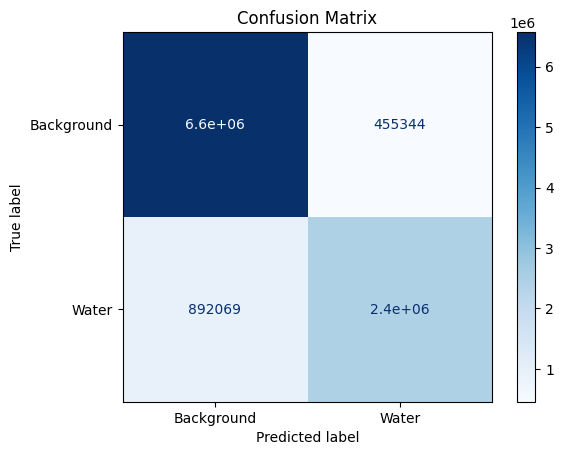

Epoch 1: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 2: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 3: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 4: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 5: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 6: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 7: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 8: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 9: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 10: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 11: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 12: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856, Val Dice=0.7833
Epoch 13: Train IoU=0.6469, Val IoU=0.6438, Train Dice=0.7856

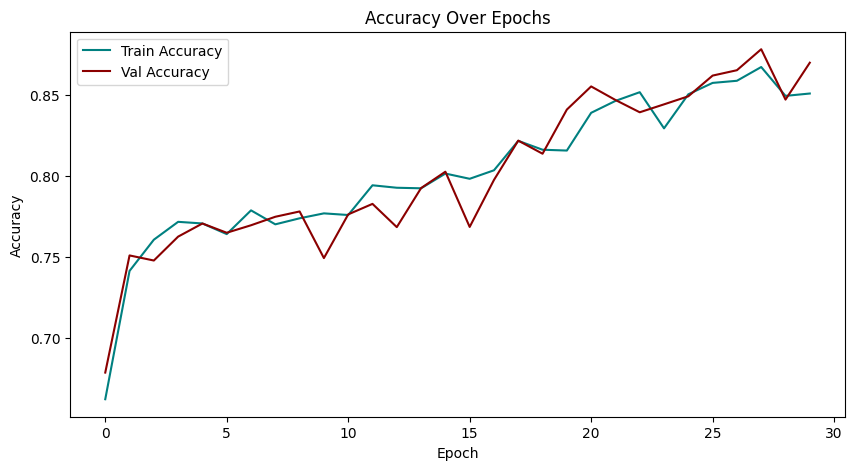

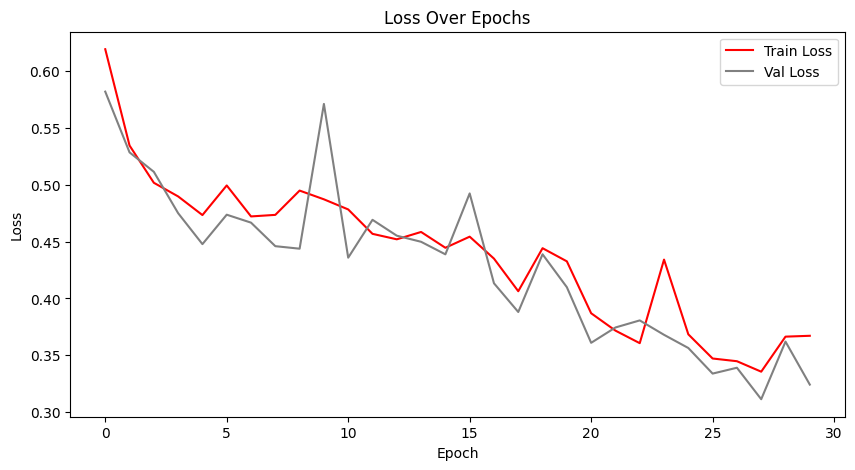

In [ ]:
# Confusion matrix
all_preds = model.predict(valid_images)
true_classes = np.argmax(valid_masks, axis=-1).flatten()
pred_classes = np.argmax(all_preds, axis=-1).flatten()
cm = confusion_matrix(true_classes, pred_classes)
ConfusionMatrixDisplay(cm, display_labels=['Background', 'Water']).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Metrics over epochs
def iou_metric(y_true, y_pred):
    y_true = tf.cast(tf.argmax(y_true, axis=-1), tf.float32)
    y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def dice_coef(y_true, y_pred):
    y_true = tf.cast(tf.argmax(y_true, axis=-1), tf.float32)
    y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + 1e-6) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-6)

train_ious, val_ious, train_dices, val_dices = [], [], [], []
for epoch in range(len(history.history['loss'])):
    train_preds = model.predict(train_images, verbose=0)
    val_preds = model.predict(valid_images, verbose=0)
    train_ious.append(iou_metric(train_masks, train_preds).numpy())
    val_ious.append(iou_metric(valid_masks, val_preds).numpy())
    train_dices.append(dice_coef(train_masks, train_preds).numpy())
    val_dices.append(dice_coef(valid_masks, val_preds).numpy())
    print(f"Epoch {epoch+1}: Train IoU={train_ious[-1]:.4f}, Val IoU={val_ious[-1]:.4f}, Train Dice={train_dices[-1]:.4f}, Val Dice={val_dices[-1]:.4f}")

print("\n\U0001F4CA Final Scores After Last Epoch:")





# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='teal')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='darkred')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='gray')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()